<a href="https://colab.research.google.com/github/mansiwahane2425-cmd/Python-ml/blob/main/Copy_of_yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:

!unzip "/content/gdrive/MyDrive/Brain Tumor YOLO dataset.zip" -d "/content/"

Archive:  /content/gdrive/MyDrive/Brain Tumor YOLO dataset.zip
 extracting: /content/README.dataset.txt  
 extracting: /content/README.roboflow.txt  
 extracting: /content/data.yaml      
   creating: /content/test/
   creating: /content/test/images/
 extracting: /content/test/images/y701_jpg.rf.81a4472f77fdc1f31537342ceca340c9.jpg  
 extracting: /content/test/images/y702_jpg.rf.bc09b4ae34c8da942f93ad0d60d6f05f.jpg  
 extracting: /content/test/images/y703_jpg.rf.2b6fdf1363f8dfa6dbfe7f72e8a23133.jpg  
 extracting: /content/test/images/y704_jpg.rf.fea190a70904afe21b7479aefa60e661.jpg  
 extracting: /content/test/images/y705_jpg.rf.254d261010e9cb81690397999575ce83.jpg  
 extracting: /content/test/images/y706_jpg.rf.93ece8603f087f1d105943420a5dd89f.jpg  
 extracting: /content/test/images/y707_jpg.rf.eda3de4a5db9174097c426944218c338.jpg  
 extracting: /content/test/images/y708_jpg.rf.e6d6f68dc83014b88ff022310d5e0223.jpg  
 extracting: /content/test/images/y709_jpg.rf.4abcd82db5678b76d44c839

In [ ]:
### 3. Install packages ###

!git clone https://github.com/autogyro/yolo-V8.git
!cd yolo-V8/ && pip install ultralytics

Cloning into 'yolo-V8'...
remote: Enumerating objects: 2723, done.
remote: Total 2723 (delta 0), reused 0 (delta 0), pack-reused 2723 (from 1)
Receiving objects: 100% (2723/2723), 1.41 MiB | 4.04 MiB/s, done.
Resolving deltas: 100% (1854/1854), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.0 MB/s eta 0:00:00


In [ ]:
### 4. Train model ###

import os

from ultralytics import YOLO


config_path = '/content/data.yaml'


!yolo task=detect mode=train model=yolov8n.pt data={config_path} epochs=50 imgsz=640 plots=True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, i

In [ ]:
# ------------------ Fix for Encoding Issues ------------------
# Sometimes, especially on platforms like Google Colab or Windows,
# you might face locale/encoding issues when running external commands.
# So, you override 'getpreferredencoding' to always return 'UTF-8'.

import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"

# Patch the 'locale' module's getpreferredencoding method
locale.getpreferredencoding = getpreferredencoding

# ------------------ Run YOLOv8 Validation ------------------
# This command runs validation (evaluation) of a trained YOLO model.

!yolo task=detect mode=val model=runs/detect/train/weights/best.pt data=/content/data.yaml save_json=True

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1787.1±328.6 MB/s, size: 65.9 KB)
val: Scanning /content/valid/labels.cache... 201 images, 74 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 201/201 26.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.2it/s 3.1s
                   all        201        128      0.721      0.883      0.781      0.655
Speed: 3.1ms preprocess, 4.5ms inference, 0.0ms loss, 2.2ms postprocess per image
Saving /content/runs/detect/val/predictions.json...
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/1 /content/test/images/y701_jpg.rf.81a4472f77fdc1f31537342ceca340c9.jpg: 640x640 1 Tumor, 9.6ms
Speed: 2.7ms preprocess, 9.6ms inference, 16.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


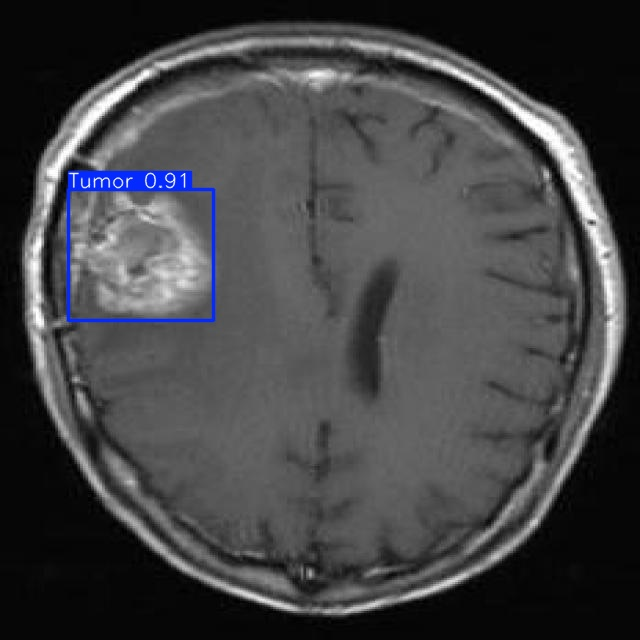

In [ ]:
from IPython.display import Image, display
import glob

!yolo predict model=/content/runs/detect/train/weights/best.pt \
              source=/content/test/images/y701_jpg.rf.81a4472f77fdc1f31537342ceca340c9.jpg \
              project=/content/runs/detect \
              name=predict \
              exist_ok=True


# Find the path of the predicted image (YOLOv8 saves output in 'runs/detect/predict' by default)
predicted_images = glob.glob('/content/runs/detect/predict/*.jpg')  # or .png if needed

# Display the first predicted image
if predicted_images:
    display(Image(filename=predicted_images[0]))
else:
    print("No predicted images found.")



image 1/1 /content/test/images/y705_jpg.rf.254d261010e9cb81690397999575ce83.jpg: 640x640 1 Tumor, 8.5ms
Speed: 2.8ms preprocess, 8.5ms inference, 15.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predictions
1 label saved to /content/runs/detect/predictions/labels

image 1/1 /content/test/images/y763_jpg.rf.1c63e12d7a70ab9514f021a3161b4bf1.jpg: 640x640 1 Tumor, 6.4ms
Speed: 2.5ms preprocess, 6.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predictions
2 labels saved to /content/runs/detect/predictions/labels

image 1/1 /content/test/images/y758_jpg.rf.6b00b4abb3abf1c03ce669b430fb6e74.jpg: 640x640 1 Tumor, 5.8ms
Speed: 2.2ms preprocess, 5.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predictions
3 labels saved to /content/runs/detect/predictions/labels

image 1/1 /content/test/images/y757_jpg.rf.48417670ad6f632d25c4268f0a5fd

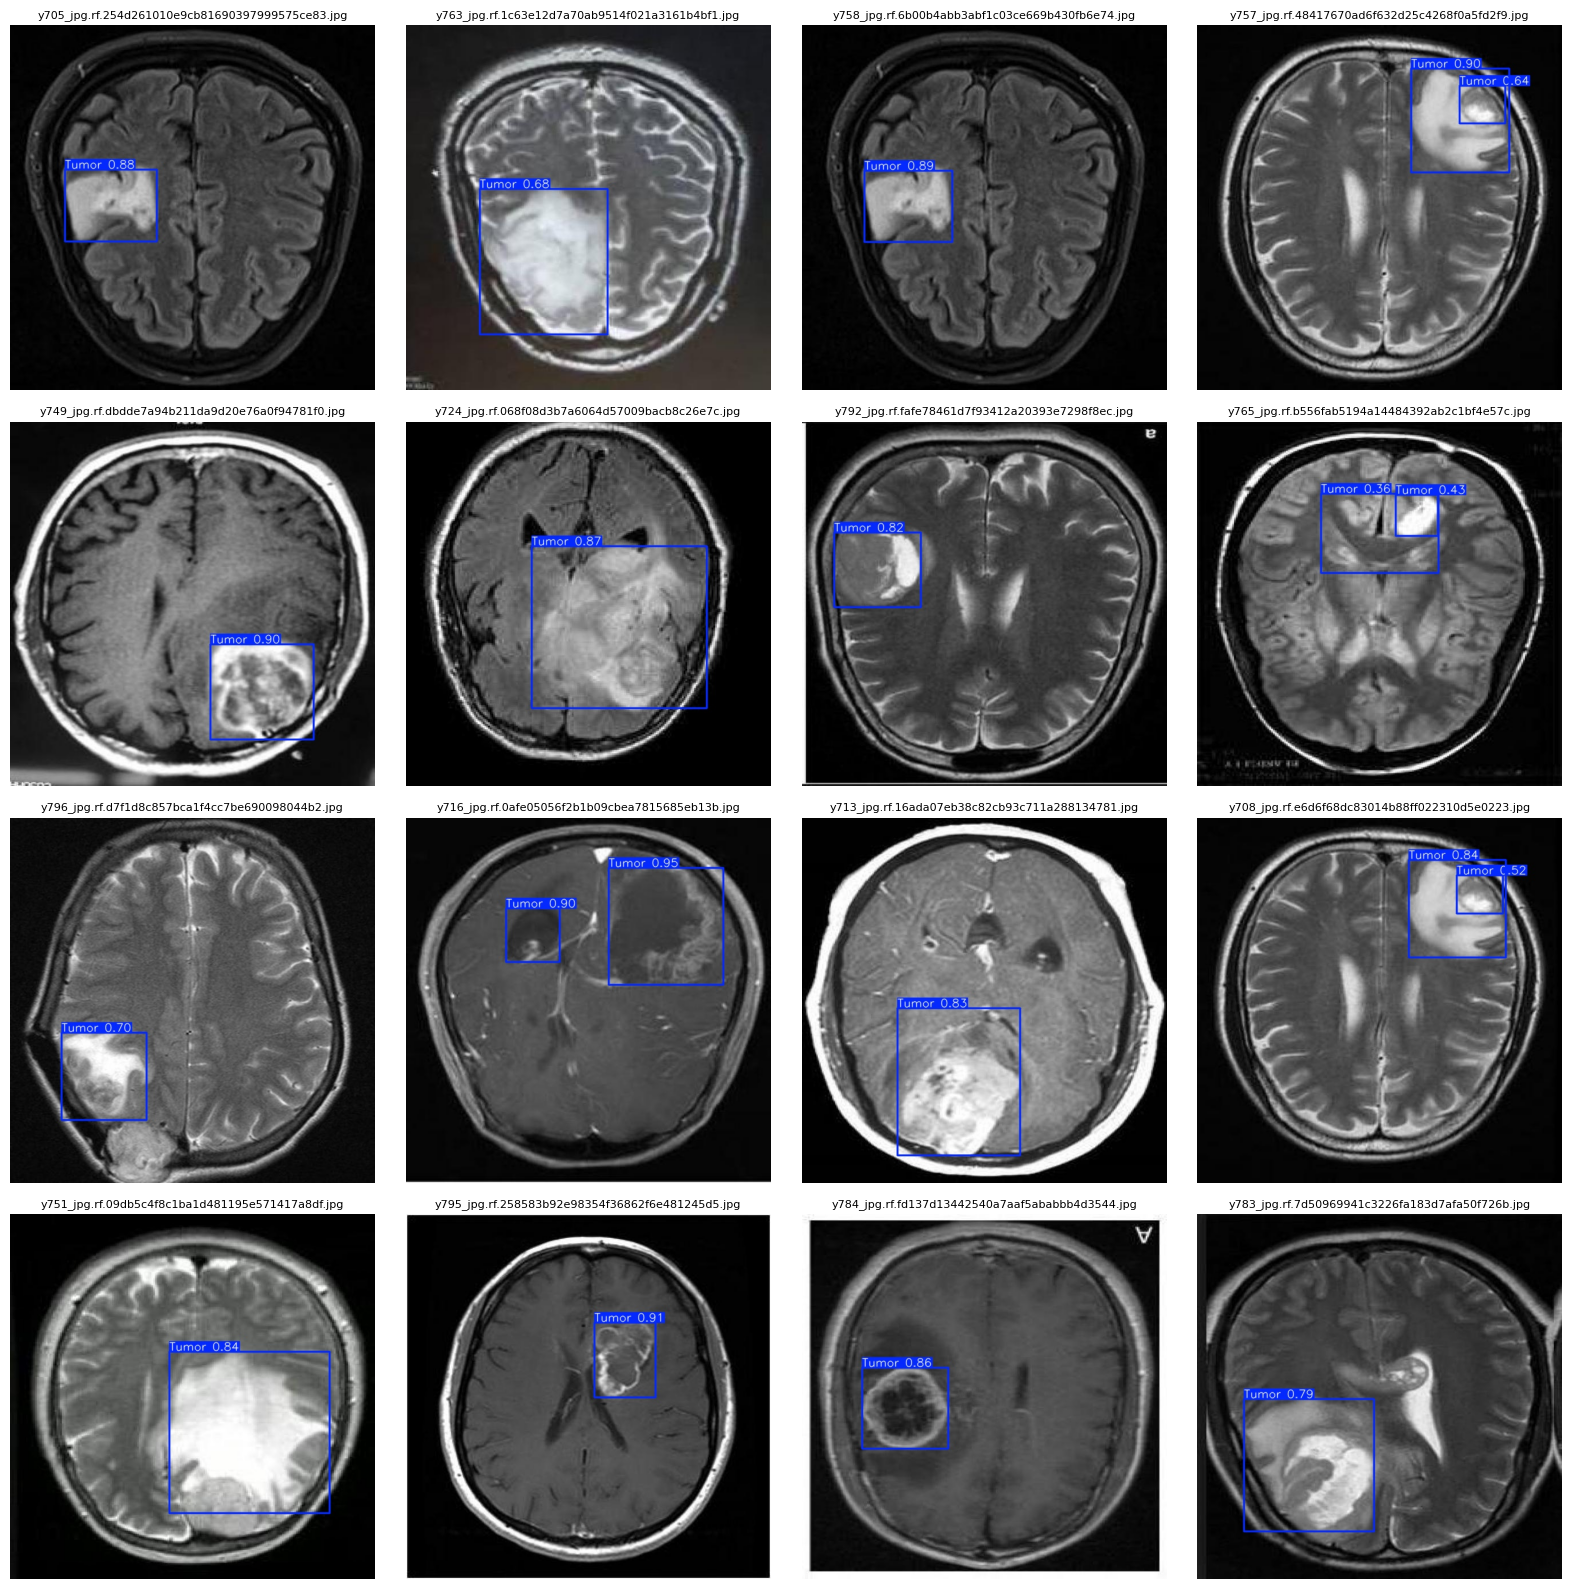

In [ ]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Paths
test_folder = '/content/test/images'
output_folder = '/content/runs/detect'
output_name = 'predictions'
output_path = os.path.join(output_folder, output_name)

# Ensure output directory exists
os.makedirs(output_path, exist_ok=True)

# Load model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Select up to 16 test images
test_images = [os.path.join(test_folder, img) for img in os.listdir(test_folder) if img.endswith(('.jpg', '.png'))][:16]

# Run predictions and save
results = []
for img_path in test_images:
    result = model.predict(source=img_path, save=True, save_txt=True, project=output_folder, name=output_name, exist_ok=True)
    results.append(result)

# Gather predicted image paths
predicted_images = [os.path.join(output_path, os.path.basename(img_path)) for img_path in test_images]

# Display images in 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, img_path in enumerate(predicted_images):
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(os.path.basename(img_path), fontsize=8)
        axes[i].axis('off')
    else:
        axes[i].axis('off')
        axes[i].set_title("Image not found", fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
### 5. Download results ###

from google.colab import files


!zip -r /content/runs.zip /content/runs

files.download('/content/runs.zip')

  adding: content/runs/ (stored 0%)
  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/val_batch1_pred.jpg (deflated 7%)
  adding: content/runs/detect/train/confusion_matrix_normalized.png (deflated 36%)
  adding: content/runs/detect/train/val_batch2_labels.jpg (deflated 7%)
  adding: content/runs/detect/train/val_batch0_pred.jpg (deflated 9%)
  adding: content/runs/detect/train/train_batch2.jpg (deflated 3%)
  adding: content/runs/detect/train/BoxP_curve.png (deflated 18%)
  adding: content/runs/detect/train/train_batch1.jpg (deflated 7%)
  adding: content/runs/detect/train/weights/ (stored 0%)
  adding: content/runs/detect/train/weights/best.pt (deflated 10%)
  adding: content/runs/detect/train/weights/last.pt (deflated 10%)
  adding: content/runs/detect/train/train_batch1280.jpg (deflated 10%)
  adding: content/runs/detect/train/val_batch2_pred.jpg (deflated 7%)
  adding: content/runs/detect/train/train_bat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>